2.1 Define Dataset Path

In [1]:
import os
DATASET_PATH = "data"
os.listdir(DATASET_PATH)

['car', 'video.mp4']

In [2]:
CAR_PATH = "data/car/"
os.listdir(CAR_PATH)

['data.yaml',
 'README.dataset.txt',
 'README.roboflow.txt',
 'test',
 'train',
 'valid']

2.2 Inspect Data Configuration

In [3]:
YAML_PATH = os.path.join(CAR_PATH, "data.yaml")

with open(YAML_PATH, "r") as f:
    print(f.read())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 15
names: ['Green Light', 'Red Light', 'Speed Limit 10', 'Speed Limit 100', 'Speed Limit 110', 'Speed Limit 120', 'Speed Limit 20', 'Speed Limit 30', 'Speed Limit 40', 'Speed Limit 50', 'Speed Limit 60', 'Speed Limit 70', 'Speed Limit 80', 'Speed Limit 90', 'Stop']

roboflow:
  workspace: selfdriving-car-qtywx
  project: self-driving-cars-lfjou
  version: 6
  license: CC BY 4.0
  url: https://universe.roboflow.com/selfdriving-car-qtywx/self-driving-cars-lfjou/dataset/6


2.3 Verify Train /Validation /Test Structure


In [4]:
for split in ["train","valid","test"]:
    split_path = os.path.join(CAR_PATH,split)


    print(f"\n{'=' * 40}")
    print(f"{split.upper()}")
    print(f"{'=' * 40}")

    print(os.listdir(split_path))
    



TRAIN
['images', 'labels']

VALID
['images', 'labels']

TEST
['images', 'labels']


2.4 Quantify the Dataset

In [5]:
from pathlib import Path
for split in ['train','valid','test']:
    image_dir = Path(CAR_PATH) / split / 'images'
    label_dir = Path(CAR_PATH) / split / 'labels'

    image_file = list(image_dir.glob('*'))
    label_file = list(label_dir.glob('*.txt'))

    #Print out

    print(f"\n{'=' * 40}")
    print(f"{split.upper()}")
    print(f"{'=' * 40}")

    print(f"Image          : {len(image_file)}")
    print(f"Label file     : {len(label_file)}")


TRAIN
Image          : 3530
Label file     : 3530

VALID
Image          : 801
Label file     : 801

TEST
Image          : 638
Label file     : 638


2.5 Class Definition

In [6]:
import yaml

In [7]:
with open(YAML_PATH,'r') as f:
    data_config = yaml.safe_load(f)

names = data_config['names']
nc = data_config['nc']
print(f"Number of classes : {nc}\n")

for class_id, class_name in enumerate(names):
    print(f"{class_id:2d} -> {class_name}")

Number of classes : 15

 0 -> Green Light
 1 -> Red Light
 2 -> Speed Limit 10
 3 -> Speed Limit 100
 4 -> Speed Limit 110
 5 -> Speed Limit 120
 6 -> Speed Limit 20
 7 -> Speed Limit 30
 8 -> Speed Limit 40
 9 -> Speed Limit 50
10 -> Speed Limit 60
11 -> Speed Limit 70
12 -> Speed Limit 80
13 -> Speed Limit 90
14 -> Stop


In [8]:
from collections import Counter
class_counts = Counter()

for split in ["train","valid","test"]:
    label_dir = Path(CAR_PATH) / split / 'labels'
    for label_file in label_dir.glob("*.txt"):

        with open (label_file , 'r') as f:
            for line in f:
                if line.strip():
                    class_id = int(line.split()[0])
                    class_counts[class_id] += 1
print("Object counts by class:\n")
for class_id, class_name in enumerate(names):
    print(f"{class_id:2d} -> {class_name:<20} : {class_counts[class_id]}")


Object counts by class:

 0 -> Green Light          : 774
 1 -> Red Light            : 787
 2 -> Speed Limit 10       : 22
 3 -> Speed Limit 100      : 365
 4 -> Speed Limit 110      : 139
 5 -> Speed Limit 120      : 356
 6 -> Speed Limit 20       : 387
 7 -> Speed Limit 30       : 468
 8 -> Speed Limit 40       : 343
 9 -> Speed Limit 50       : 404
10 -> Speed Limit 60       : 422
11 -> Speed Limit 70       : 449
12 -> Speed Limit 80       : 440
13 -> Speed Limit 90       : 240
14 -> Stop                 : 416


In [9]:
split_class_counts = {}
for split in ['train',"valid","test"]:
    counts = Counter()
    label_dir = Path(CAR_PATH) / split / "labels"

    for label_file in label_dir.glob("*.txt"):

        with open(label_file , "r") as f:
            for line in f:

                if line.strip():
                    class_id = int(line.split()[0])
                    counts[class_id] += 1
    split_class_counts[split] = counts
for split, counts in split_class_counts.items():

    print(f"\n{'=' * 40}")
    print(f"{split.upper()}")
    print(f"{'=' * 40}")

    for class_id, class_name in enumerate(names):
        print(f"{class_id:2d}-> {class_name:<20}  :  {counts[class_id]}")



TRAIN
 0-> Green Light           :  542
 1-> Red Light             :  585
 2-> Speed Limit 10        :  19
 3-> Speed Limit 100       :  267
 4-> Speed Limit 110       :  101
 5-> Speed Limit 120       :  252
 6-> Speed Limit 20        :  285
 7-> Speed Limit 30        :  334
 8-> Speed Limit 40        :  235
 9-> Speed Limit 50        :  283
10-> Speed Limit 60        :  301
11-> Speed Limit 70        :  318
12-> Speed Limit 80        :  323
13-> Speed Limit 90        :  168
14-> Stop                  :  285

VALID
 0-> Green Light           :  122
 1-> Red Light             :  108
 2-> Speed Limit 10        :  0
 3-> Speed Limit 100       :  52
 4-> Speed Limit 110       :  17
 5-> Speed Limit 120       :  60
 6-> Speed Limit 20        :  56
 7-> Speed Limit 30        :  74
 8-> Speed Limit 40        :  55
 9-> Speed Limit 50        :  71
10-> Speed Limit 60        :  76
11-> Speed Limit 70        :  78
12-> Speed Limit 80        :  56
13-> Speed Limit 90        :  38
14-> Stop     

In [10]:
import pandas as pd

distribution_df = pd.DataFrame({
    "class_id": range(len(names)),
    "class_name": names,
    "train": [split_class_counts["train"][i] for i in range(len(names))],
    "valid": [split_class_counts["valid"][i] for i in range(len(names))],
    "test": [split_class_counts["test"][i] for i in range(len(names))]
})

distribution_df["total"] = (
    distribution_df["train"]
    + distribution_df["valid"]
    + distribution_df["test"]
)

distribution_df

,class_id,class_name,train,valid,test,total
0,0,Green Light,542,122,110,774
1,1,Red Light,585,108,94,787
2,2,Speed Limit 10,19,0,3,22
3,3,Speed Limit 100,267,52,46,365
4,4,Speed Limit 110,101,17,21,139
5,5,Speed Limit 120,252,60,44,356
6,6,Speed Limit 20,285,56,46,387
7,7,Speed Limit 30,334,74,60,468
8,8,Speed Limit 40,235,55,53,343
9,9,Speed Limit 50,283,71,50,404


In [11]:
object_per_image ={}
for split in ["train","valid","test"]:
    label_dir = Path(CAR_PATH) / split / "labels"

    object_counts = []

    for label_file in label_dir.glob('*.txt'):
        with open(label_file,'r') as f:
            count = sum(1 for line in f if line.strip())

        object_counts.append(count)
    object_per_image[split] = object_counts

for split,counts in object_per_image.items():
    print(f"\n{'=' *40}")
    print(f"{split.upper()}")
    print(f"{'=' * 40}")

    print(f"Image             : {len(counts)}")
    print(f"Total objects     : {len(counts)}")
    print(f"Average objects   : {len(counts)/len(counts):.2f}")
    print(f"Minimum objects   : {min(counts)}")
    print(f"Maximum objects   : {max(counts)}")


TRAIN
Image             : 3530
Total objects     : 3530
Average objects   : 1.00
Minimum objects   : 0
Maximum objects   : 7

VALID
Image             : 801
Total objects     : 801
Average objects   : 1.00
Minimum objects   : 1
Maximum objects   : 6

TEST
Image             : 638
Total objects     : 638
Average objects   : 1.00
Minimum objects   : 0
Maximum objects   : 10


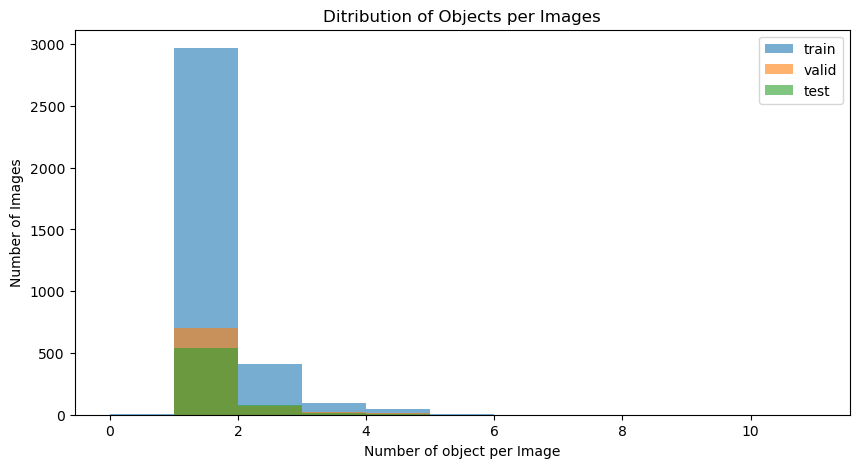

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for split,counts in object_per_image.items():
    plt.hist(counts,bins=range(0,max(counts) + 2), alpha=0.6,label=split)


plt.xlabel("Number of object per Image")
plt.ylabel("Number of Images")
plt.title("Ditribution of Objects per Images")
plt.legend()
plt.show()

3.3 Image Dimensions

In [13]:
from PIL import Image
from collections import Counter

image_dimensions = {}

for split in ["train","valid","test"]:

    image_dir = Path(CAR_PATH) / split / "images"
    dimensions = []
    for image_file in image_dir.iterdir():
        try:
            with Image.open(image_file) as img:
                dimensions.append(img.size)
        except Exception as e:
            print(f"Could not read {image_file.name} : {e}")

image_dimensions[split] = dimensions
    
dimension_counts = Counter(dimensions)
    
print(f"\n{'=' * 40}")
print(f"{split.upper()}")
print(f"{'=' * 40}")
    
print(f"Images: {len(dimensions)}")
print(f"Unique dimensions: {len(dimension_counts)}")
    
print("\nMost common dimensions:")
for dimension, count in dimension_counts.most_common(10):
    print(f"{dimension} → {count} images")


TEST
Images: 638
Unique dimensions: 1

Most common dimensions:
(416, 416) → 638 images


3.4 Bounding Box Analysis

In [14]:

import numpy as np
bbox_records  = []

for split in ["train", "valid", "test"]:

    label_dir = Path(CAR_PATH) / split / "labels"

    for label_file in label_dir.glob("*.txt"):
        with open(label_file,'r') as f:
            for line in f:
                if not line.strip():
                    continue
                values = line.split()

                class_id = int(values[0])
                x_center = float(values[1])
                y_center = float(values[2])
                width = float(values[3])
                height = float(values[4])

                bbox_records.append(
                    {
                        "split" : split,
                        "class_id":class_id,
                        "class_name":class_name,
                        "x_center" : x_center,
                        "y_center" : y_center,
                        "width_norm" : width,
                        "height_norm" : height,
                        "width_px" : width * 416,
                        "height_px" : height * 416,
                        "area_ratio" : width * height
                    }
                )

bbox_df = pd.DataFrame(bbox_records)
bbox_df.head()


,split,class_id,class_name,x_center,y_center,width_norm,height_norm,width_px,height_px,area_ratio
0,train,7,Stop,0.533654,0.317308,0.169471,0.317308,70.5,132.0,0.053775
1,train,7,Stop,0.576923,0.360577,0.415865,0.275240,173.0,114.5,0.114463
2,train,7,Stop,0.518029,0.485577,0.622596,0.450721,259.0,187.5,0.280617
3,train,7,Stop,0.486779,0.436298,0.439904,0.289663,183.0,120.5,0.127424
4,train,7,Stop,0.317308,0.534856,0.402644,0.596154,167.5,248.0,0.240038


In [15]:
print(f"Total bounding boxes: {len(bbox_df):,}")

print("\nBounding-box statistics:")
print(
    bbox_df[
        ["width_norm", "height_norm", "width_px", "height_px", "area_ratio"]
    ].describe()
)

Total bounding boxes: 6,012

Bounding-box statistics:
        width_norm  height_norm     width_px    height_px   area_ratio
count  6012.000000  6012.000000  6012.000000  6012.000000  6012.000000
mean      0.326824     0.347654   135.958916   144.623919     0.193071
std       0.283836     0.295442   118.075576   122.903946     0.221710
min       0.002404     0.002404     1.000000     1.000000     0.000009
25%       0.040865     0.061298    17.000000    25.500000     0.002510
50%       0.231971     0.254808    96.500000   106.000000     0.056982
75%       0.611779     0.638522   254.500000   265.625000     0.385351
max       1.000000     1.000000   416.000000   416.000000     0.930288


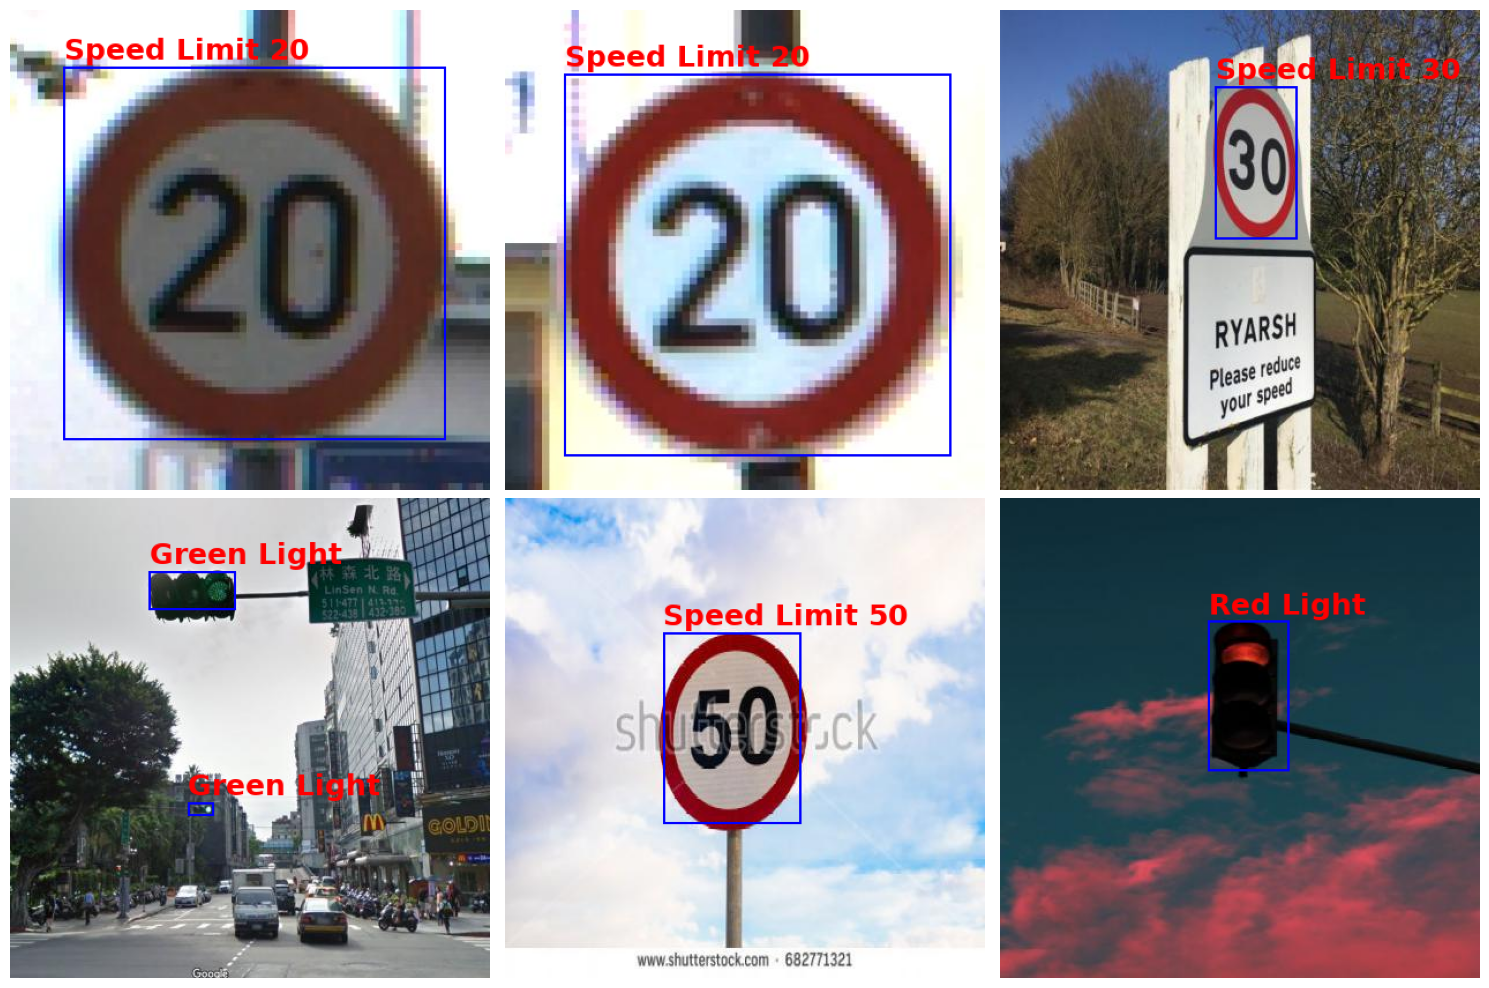

In [16]:
import random
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

FONT_SIZE = 25

try:
    font = ImageFont.truetype("DejaVuSans-Bold.ttf", FONT_SIZE)
except OSError:
    import matplotlib.font_manager as fm
    font = ImageFont.truetype(fm.findfont(fm.FontProperties(weight="bold")), FONT_SIZE)

image_dir = Path(CAR_PATH) / "train" / "images"
label_dir = Path(CAR_PATH) / "train" / "labels"

exts = {".jpg", ".jpeg", ".png", ".bmp"}
image_files = [p for p in image_dir.iterdir() if p.suffix.lower() in exts]

n = min(6, len(image_files))
sample_images = random.sample(image_files, n)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, image_file in zip(axes.ravel(), sample_images):
    image = Image.open(image_file).convert("RGB")
    draw = ImageDraw.Draw(image)
    img_w, img_h = image.size

    label_file = label_dir / f"{image_file.stem}.txt"

    if label_file.exists():
        with open(label_file, "r") as f:
            for line in f:
                values = line.split()
                if len(values) < 5:          # skip blank/short lines
                    continue

                class_id = int(values[0])
                x_center, y_center, width, height = map(float, values[1:5])

                x1 = (x_center - width / 2) * img_w
                y1 = (y_center - height / 2) * img_h
                x2 = (x_center + width / 2) * img_w
                y2 = (y_center + height / 2) * img_h

                draw.rectangle([x1, y1, x2, y2], outline="blue", width=2)
                draw.text(
                    (x1, max(0, y1 - FONT_SIZE - 5)),
                    names[class_id],
                    fill="red",
                    font=font,
                )

    ax.imshow(image)
    ax.axis("off")

for ax in axes.ravel()[n:]:      # hide unused panes if fewer than 6 images
    ax.axis("off")

plt.tight_layout()
plt.show()

4. Dataset Validation

4.1 Image-label Consistency

In [17]:
image_extensions = {".jpg", ".jpeg", ".png",".bmp",".webp"}


for split in ["train","valid","test"]:

 print(split)
 image_steams ={
  file.stem
  for file in image_dir.iterdir()
  if file.suffix.lower() in image_extensions
 }

 label_stems ={
  file.stem
  for file in label_dir.glob("*.txt")
 }


 missing_labels = image_steams - label_stems
 missing_images = label_stems - image_steams


 print(f"\n{'=' * 40}")
 print(split.upper())
 print(f"{'=' * 40}")
 print(f"Images without labels   : {len(missing_labels)}")
 print(f"Missing Image           : {len(missing_images)}")

train

TRAIN
Images without labels   : 0
Missing Image           : 0
valid

VALID
Images without labels   : 0
Missing Image           : 0
test

TEST
Images without labels   : 0
Missing Image           : 0


4.2 Annotation Validity

In [18]:
invalid_annotations = []
for split in ["train","valid","test"]:
    for label_file in label_dir.glob('*.txt'):
        with open(label_file,"r") as f:
            for line_number,line in enumerate(f,start=1):
                if not line.split():
                    continue


                values = line.split()


                if len(values) != 5 :
                    invalid_annotations.append(
                        (split,label_file.name,line_number,"Incorrect number of values")
                    )
                    continue
                try:
                    class_id = int(values[0])
                    x_center,y_center,width,height = map(float,values[1:])
                except ValueError:
                    invalid_annotations.append(
                        (split,label_file.name,line_number,"Invalid class ID")
                    )
                if not (0 <= x_center <=1 and 
                        0 <= y_center <=1 and 
                        0 <= width <=1 and 
                        0 <= height <=1 ):
                    invalid_annotations.append(
                        (split,label_file.name,line_number,"Invalid bouding box")
                    )
print(f"Invalid annotations found: {len(invalid_annotations)}")

if invalid_annotations:
    for item in invalid_annotations[:10]:
        print(item)

Invalid annotations found: 0


4.3 Empty Annotation Files

In [19]:
empty_images = {}

for split in ["train", "valid", "test"]:
    
    label_dir = Path(CAR_PATH) / split / "labels"
    empty_files = []

    for label_file in label_dir.glob("*.txt"):
        with open(label_file, "r") as f:
            content = f.read().strip()

        if not content:
            empty_files.append(label_file)

    empty_images[split] = empty_files

    print(f"{split}: {len(empty_files)} empty label files")

train: 3 empty label files
valid: 0 empty label files
test: 1 empty label files


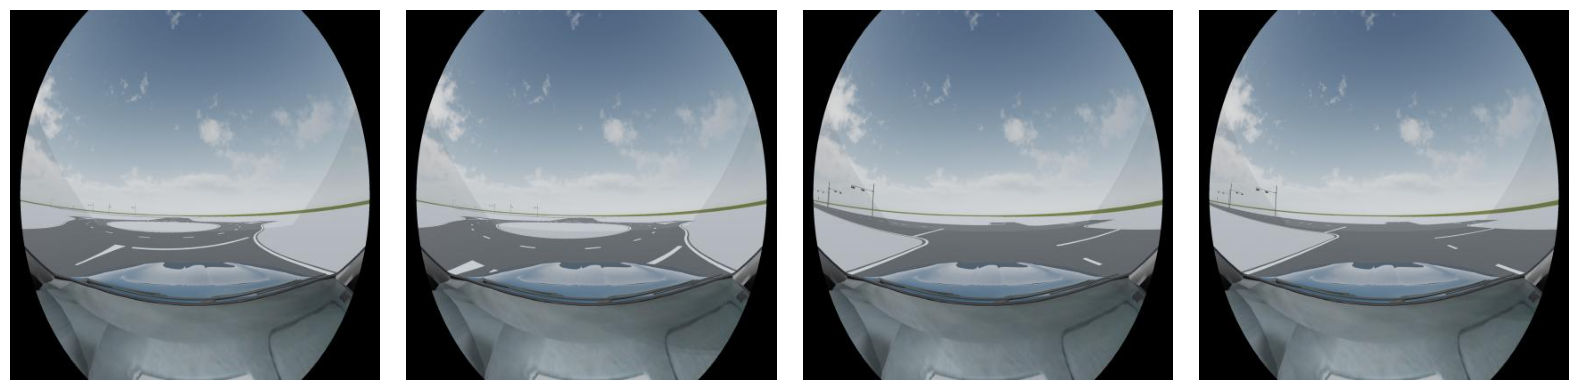

In [20]:
empty_samples = []

for split in ["train", "valid", "test"]:
    image_dir = Path(CAR_PATH) / split / "images"

    for label_file in empty_images[split]:
        image_file = next(
            (
                f for f in image_dir.iterdir()
                if f.stem == label_file.stem
            ),
            None
        )

        if image_file:
            empty_samples.append((split, image_file))

fig, axes = plt.subplots(
    1,
    len(empty_samples),
    figsize=(16, 4)
)

for ax, (split, image_file) in zip(axes, empty_samples):

    image = Image.open(image_file).convert("RGB")

    ax.imshow(image)
    ax.axis("off")

plt.tight_layout()
plt.show()

4.4 Tiny Bounding Boxes

In [21]:
tiny_boxes = bbox_df[
    (bbox_df["width_px"] <= 5) |
    (bbox_df["height_px"] <= 5)
].copy()

print(f"Bounding boxes with width or height <= 5 px: {len(tiny_boxes)}")

tiny_boxes[
    ["split", "class_name", "width_px", "height_px", "area_ratio"]
].sort_values("area_ratio").head(20)

Bounding boxes with width or height <= 5 px: 655


,split,class_name,width_px,height_px,area_ratio
3003,train,Stop,1.5,1.0,0.000009
5013,valid,Stop,2.0,1.0,0.000012
3002,train,Stop,2.0,1.0,0.000012
3004,train,Stop,2.5,1.0,0.000014
3024,train,Stop,2.5,1.0,0.000014
5009,valid,Stop,2.0,1.5,0.000017
5014,valid,Stop,2.0,1.5,0.000017
3013,train,Stop,2.0,1.5,0.000017
3001,train,Stop,2.0,1.5,0.000017
3010,train,Stop,2.0,1.5,0.000017


In [22]:
tiny_samples = (
    bbox_df[
        (bbox_df["width_px"] <= 5) |
        (bbox_df["height_px"] <= 5)
    ]
    .sort_values("area_ratio")
    .head(6)
)

tiny_samples

,split,class_id,class_name,x_center,y_center,width_norm,height_norm,width_px,height_px,area_ratio
3003,train,1,Stop,0.462740,0.516827,0.003606,0.002404,1.5,1.0,0.000009
5013,valid,1,Stop,0.456731,0.510817,0.004808,0.002404,2.0,1.0,0.000012
3002,train,1,Stop,0.463942,0.516827,0.004808,0.002404,2.0,1.0,0.000012
3004,train,1,Stop,0.485577,0.516827,0.006010,0.002404,2.5,1.0,0.000014
3024,train,1,Stop,0.461538,0.513221,0.006010,0.002404,2.5,1.0,0.000014
5009,valid,1,Stop,0.460337,0.514423,0.004808,0.003606,2.0,1.5,0.000017


In [23]:
bbox_records = []

for split in ["train", "valid", "test"]:
    
    label_dir = Path(CAR_PATH) / split / "labels"
    
    for label_file in label_dir.glob("*.txt"):
        
        with open(label_file, "r") as f:
            for line in f:
                
                if not line.strip():
                    continue
                
                values = line.split()
                
                class_id = int(values[0])
                x_center, y_center, width, height = map(float, values[1:])
                
                bbox_records.append({
                    "split": split,
                    "label_file": label_file.name,
                    "class_id": class_id,
                    "class_name": names[class_id],
                    "x_center": x_center,
                    "y_center": y_center,
                    "width_norm": width,
                    "height_norm": height,
                    "width_px": width * 416,
                    "height_px": height * 416,
                    "area_ratio": width * height
                })

bbox_df = pd.DataFrame(bbox_records)

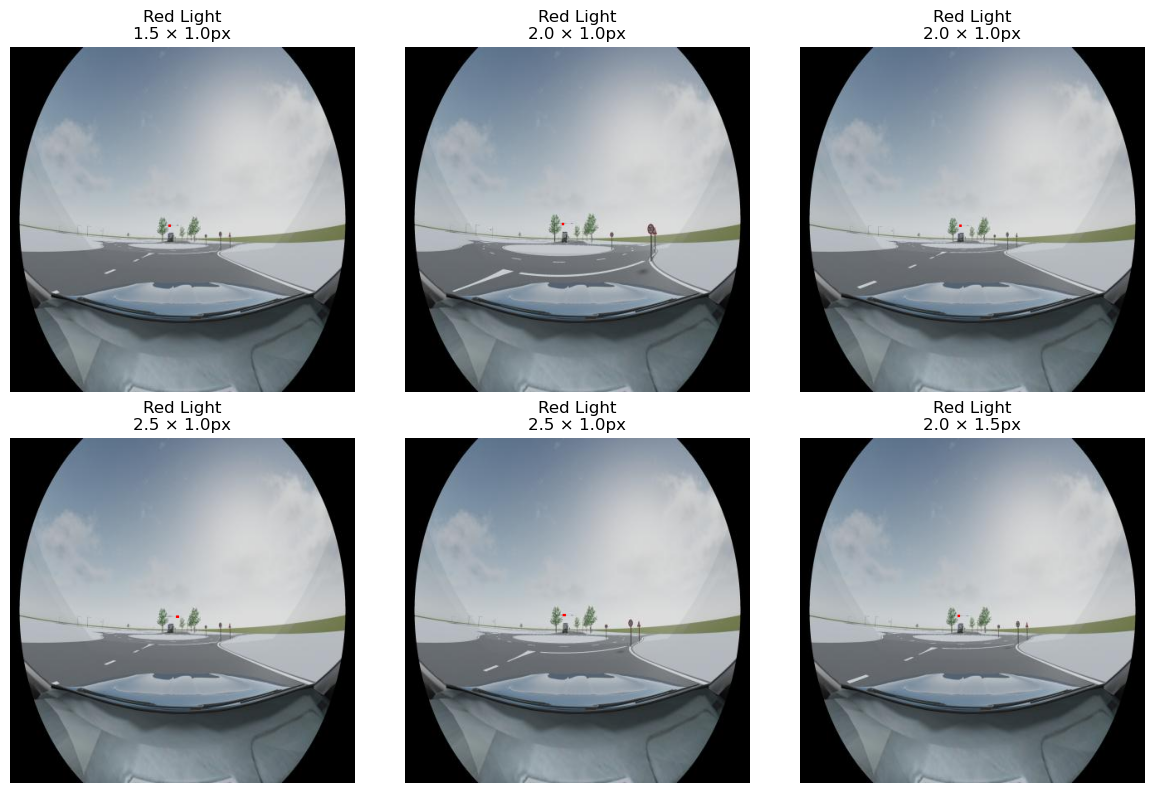

In [24]:
tiny_samples = (
    bbox_df[
        (bbox_df["width_px"] <= 5) |
        (bbox_df["height_px"] <= 5)
    ]
    .sort_values("area_ratio")
    .head(6)
)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, (_, row) in zip(axes.ravel(), tiny_samples.iterrows()):

    image_path = (
        Path(CAR_PATH)
        / row["split"]
        / "images"
        / row["label_file"].replace(".txt", ".jpg")
    )

    image = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(image)

    img_w, img_h = image.size

    x = row["x_center"]
    y = row["y_center"]
    w = row["width_norm"]
    h = row["height_norm"]

    x1 = (x - w / 2) * img_w
    y1 = (y - h / 2) * img_h
    x2 = (x + w / 2) * img_w
    y2 = (y + h / 2) * img_h

    draw.rectangle(
        [x1, y1, x2, y2],
        outline="red",
        width=2
        
    )

    ax.imshow(image)
    ax.set_title(
        f'{row["class_name"]}\n'
        f'{row["width_px"]:.1f} × {row["height_px"]:.1f}px'
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

In [25]:
!pip install -q ultralytics

In [26]:
from ultralytics import YOLO
import ultralytics
print(f"Ultralytics version {ultralytics.__version__}")

Ultralytics version 8.4.116


5.2 Loading the dataset


In [27]:
model = YOLO('yolov8n.pt')

In [28]:
import torch

print("PyTorch version:", torch.__version__)
print("PyTorch CUDA version:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("Device count:", torch.cuda.device_count())

PyTorch version: 2.11.0+cu128
PyTorch CUDA version: 12.8
CUDA available: True
Device count: 1


In [29]:
import torch
print("CUDA available : ",torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU : ",torch.cuda.get_device_name(0))

CUDA available :  True
GPU :  NVIDIA GeForce RTX 3070


In [ ]:
yaml_path = "data/car/data.yaml"

results = model.train(
    data=yaml_path,
    epochs=30,
    imgsz=640,
    batch=-1,
    optimizer="auto",
    device=0,
    save=True,
    plots=True,
    project="/kaggle/working/traffic-signs",
    name="yolov8n_baseline"
)

New https://pypi.org/project/ultralytics/8.4.123 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.116  Python-3.10.20 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3070, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/car/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=tra

In [ ]:
from IPython.display import Image, display

display(
    Image(
        filename="data/results.png"
    )
)